# Tennis Betting Model

## Load and Clean Data

### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

### Load Data

In [17]:
def get_df_from_folder(folder_path):

    # Create empty list for dfs 
    dfs = []

    # Iterate through files in folder
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        df = pd.read_excel(file_path)
        dfs.append(df)

    # Concatenate into one dataframe
    df = pd.concat(dfs)

    # Reset index
    df = df.reset_index(drop=True)

    return df


We can extract only the relevant columns:

In [18]:
# Get folder path
folder_path = 'match_datasets_atp/'

# Run above function to get dataframe
df = get_df_from_folder(folder_path)

c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [19]:
def create_winner_loser_dfs(df):

    # Extract necessary columns
    df2 = df[['Winner', 'Loser', 'Surface', 'Round','Date','WRank', 'LRank', 'WPts', 'LPts', 'Wsets',
        'Lsets', 'MaxW', 'MaxL']]
    
    # Create copies for winners and losers
    df_winners = df2.copy()
    df_losers = df2.copy()

    # Drop odds columns for opposite outcome
    df_winners = df_winners.drop('MaxL', axis=1)
    df_losers = df_losers.drop('MaxW', axis=1)

    # Create addtional feature based on rank difference:
    df_winners['rank_diff'] = df_winners['WRank'] - df_winners['LRank']
    df_losers['rank_diff'] = df_losers['LRank'] - df_losers['WRank']

    # Create addtional feature based on point difference:
    df_losers['pts_diff'] = df_losers['LPts'] - df_losers['WPts']
    df_winners['pts_diff'] = df_winners['WPts'] - df_winners['LPts']

    # Create a column for whether the player won the match 
    # which will ultimately be our target variable:
    df_winners['won'] = 1
    df_losers['won'] = 0

    # Next we can create features based on a 'score' value where a score is positive or negative 
    # based on whether a player won the match, and inversely proportional to the rank or points 
    # difference between competitors (i.e. a player will receive a lower score for beating a 
    # competitor with a lower rank when compared to beating a competitor with a higher rank)

    # Get lowest rank and highest points
    lowest_rank = df[['WRank', 'LRank']].max().max()
    highest_pts = df[['WPts', 'LPts']].max().max()

    # Create scores based on wins and rank/points
    df_winners['rank_score'] = -df_winners['rank_diff'] + lowest_rank
    df_losers['rank_score'] = -df_losers['rank_diff'] - lowest_rank

    df_winners['pts_score'] = -df_winners['pts_diff'] + highest_pts
    df_losers['pts_score'] = -df_losers['pts_diff'] - highest_pts

    # We can also create similar scores for when players have won in straight sets:
        
    # Straight sets column
    df_winners['straight_sets'] = np.where(df_winners['Lsets'] == 0, 1, 0)
    df_losers['straight_sets'] = np.where(df_losers['Lsets'] == 0, -1, 0)

    # Create scores based on straight sets and rank/points
    df_winners['ss_rank_score'] = np.where(df_winners['straight_sets'] == 1, -df_winners['rank_diff'] + lowest_rank, 0)
    df_losers['ss_rank_score'] = np.where(df_losers['straight_sets'] == -1, -df_losers['rank_diff'] - lowest_rank, 0)

    df_winners['ss_pts_score'] = np.where(df_winners['straight_sets'] == 1, -df_winners['pts_diff'] + lowest_rank, 0)
    df_losers['ss_pts_score'] = np.where(df_losers['straight_sets'] == -1, -df_losers['pts_diff'] - lowest_rank, 0)    

    # Drop columns
    df_winners = df_winners.drop(['WRank','LRank','WPts','LPts','Wsets','Lsets'], axis=1)
    df_losers = df_losers.drop(['WRank','LRank','WPts','LPts','Wsets','Lsets'], axis=1)

    # Rename player, odds and date column
    df_winners = df_winners.rename(columns={'Winner':'player', 'Loser': 'opponent', 'Date':'date', 'MaxW': 'odds'})
    df_losers = df_losers.rename(columns={'Loser':'player', 'Winner': 'opponent', 'Date':'date', 'MaxL': 'odds'})

    return df_winners, df_losers

In [20]:
# Run above function
df_winners, df_losers = create_winner_loser_dfs(df)

We can create a function to conbine these dataframes:

In [21]:
def combine_winners_losers_dfs(df_winners, df_losers):

    # Combine dataframes
    match_df = pd.concat([df_winners, df_losers])

    # Sort by player and date
    match_df = match_df.sort_values(by=['player', 'date'])

    # Reset Index
    match_df = match_df.reset_index(drop=True)

    return match_df

In [22]:
# Run above function 
match_df = combine_winners_losers_dfs(df_winners, df_losers) 

In [23]:
match_df

,player,opponent,Surface,Round,date,odds,rank_diff,pts_diff,won,rank_score,pts_score,straight_sets,ss_rank_score,ss_pts_score
0,Agamenone F.,Mcdonald M.,Clay,1st Round,2022-05-23,2.50,96.0,-534.0,0,-5011.0,-16416.0,0,0.0,0.0
1,Agamenone F.,Djere L.,Clay,1st Round,2022-07-26,5.15,59.0,-258.0,1,4856.0,17208.0,0,0.0,0.0
2,Agamenone F.,Baez S.,Clay,2nd Round,2022-07-28,6.00,104.0,-865.0,1,4811.0,17815.0,0,0.0,0.0
3,Agamenone F.,Cecchinato M.,Clay,Quarterfinals,2022-07-29,2.40,-15.0,36.0,1,4930.0,16914.0,1,4930.0,4879.0
4,Agamenone F.,Sinner J.,Clay,Semifinals,2022-07-30,8.60,126.0,-2787.0,0,-5041.0,-14163.0,-1,-5041.0,-2128.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52491,Zverev M.,Granollers M.,Grass,Quarterfinals,2019-07-19,3.24,113.0,-346.0,0,-5028.0,-16604.0,-1,-5028.0,-4569.0
52492,Zverev M.,Isner J.,Hard,1st Round,2020-02-26,3.52,237.0,-1578.0,0,-5152.0,-15372.0,-1,-5152.0,-3337.0
52493,Zverev M.,Millman J.,Hard,1st Round,2020-10-12,4.90,224.0,-978.0,1,4691.0,17928.0,1,4691.0,5893.0
52494,Zverev M.,Hurkacz H.,Hard,2nd Round,2020-10-14,3.70,237.0,-1280.0,0,-5152.0,-15670.0,-1,-5152.0,-3635.0


Now we can create a function to add addtional features for each match showing the results for each the prior ten matches to each match: 

In [24]:
def create_prior_match_features(df): 
    
    # Features to add for previous match
    features = ['rank_score', 'pts_score','ss_rank_score', 'ss_pts_score']

    # Iterate over unique players
    for player in df['player'].unique():
        # Filter dataframe for each player
        player_matches = df[df['player'] == player]

        # Shift the features
        previous_features = player_matches[features].shift(1)

        # Iterate over number of previous matches
        for i in range(1, 11):
            for feature in features:
                df.loc[player_matches.index, f'{feature}_{i}_match_ago'] = previous_features[feature]
            previous_features = previous_features.shift(1)

    # Drop all matches without ten previous matches to show stats for
    #df = df.dropna()

    return df


In [25]:
# Run above function
match_df = create_prior_match_features(match_df)

In [26]:
player_df = pd.read_csv('all_player_atts.csv')

In [27]:
player_df.dropna(subset=['name'], inplace=True) 

In [29]:
def format_name(name):
    if isinstance(name, str):
        split_name = name.split()
        if len(split_name) == 2:
            first_name = split_name[0]
            last_name = split_name[1]
            return f"{last_name} {first_name[0]}."
        else:
            return "Invalid Name"
    else:
        return "Invalid Name"

player_df['formatted_name'] = player_df['name'].apply(format_name)

In [30]:
changed_names = list(player_df[player_df['formatted_name']!='Invalid Name']['formatted_name'])
remaining_names = list(player_df[player_df['formatted_name']=='Invalid Name']['name'])
all_shortened_names = list(set(list(match_df['player'].unique()) + list(match_df['opponent'].unique())))
remaining_short_names = [name for name in all_shortened_names if name not in changed_names]


In [31]:
len(all_shortened_names)

808

In [32]:
len(remaining_short_names)

466

In [52]:
remaining_short_names

['Herbert P.H',
 'Idmbarek Y.',
 'Baluda V.',
 'Quigley E.',
 'Ahouda A.',
 'Tsitsipas P.',
 'Hanescu V.',
 'Soderlund C.',
 'Torebko P.',
 'Llodra M.',
 'Falla A.',
 'Krawietz K.',
 'Mayer L.',
 'Brown D.',
 'Baker J.',
 'Groth S.',
 'Ghedin R.',
 'Corrie E.',
 'Barrientos N.',
 'King-Turner D.',
 'Nedovyesov O.',
 'Harrison C.',
 'Smith A.',
 'Dancevic F.',
 'Cervantes I.',
 'Stakhovsky S.',
 'Davydenko P.',
 'Willis M.',
 'Gimeno Valero C.',
 'Gabashvili T.',
 'Zayid M.S.',
 'Zhang Ze.',
 'Kadhe A.',
 'Kern R.',
 'Levine J.',
 'Burquier G.',
 'Ouyang B.',
 'Caruana L.',
 'Youzhny M.',
 'Herbert P-H.',
 'Soeda G.',
 'Donaldson J.',
 'Krajicek A.',
 'Sorensen L.',
 'Mayer F.',
 'Zverev A. ',
 'Trongcharoenchaikul W.',
 'Bryde T.',
 'Garza D.',
 'Kamke T.',
 'Novikov D.',
 'Oswald P.',
 'Weintraub A.',
 'Devvarman S.',
 'Rosenholm P.',
 'Herbert P.H.',
 'Nedunchezhiyan J.',
 'Vaisse M.',
 'Zopp J.',
 'Tearney F.',
 'Mertl J.',
 'Linzer M.',
 'Garcia-Lopez G.',
 'Alund M.',
 'Mott B.',


In [33]:
for name in remaining_names:
    for short_name in remaining_short_names:
        if (short_name == 'Munoz-De La Nava D.') or (short_name == 'Garcia-Lopez G.'):
            continue
        if short_name.split()[0] in ['De', 'Del', 'O', 'Van', 'Al', 'Lopez']:
            searchable_name = short_name.split()[-2]
            if searchable_name in name:
                for i, row in player_df.iterrows():
                    if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                        player_df.loc[i, 'formatted_name'] = short_name 
        elif '-' in short_name.split()[0]:
            searchable_name = short_name.split()[0].split('-')[1]
            if searchable_name in name:
                for i, row in player_df.iterrows():
                    if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                        player_df.loc[i, 'formatted_name'] = short_name

            else:
                searchable_name = short_name.split()[0].split('-')[0]
                if searchable_name in name:
                    for i, row in player_df.iterrows():
                        if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                            player_df.loc[i, 'formatted_name'] = short_name
        else:
            searchable_name = short_name.split()[0]
            if searchable_name in name:       
                for i, row in player_df.iterrows():
                    if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                        player_df.loc[i, 'formatted_name'] = short_name
            else:
                searchable_name = short_name.split()[1]
                if searchable_name in name:
                    if (searchable_name == 'Da') or (searchable_name == 'De'):
                        pass
                    else:
                        for i, row in player_df.iterrows():
                            if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                                player_df.loc[i, 'formatted_name'] = short_name
                else:
                    try:
                        searchable_name = short_name.split()[2]
                        if searchable_name in name:
                            if l(searchable_name == 'F'):
                                pass
                            else:
                                for i, row in player_df.iterrows():
                                    if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                                        player_df.loc[i, 'formatted_name'] = short_name
                    except:
                        continue


In [129]:
changed_names = list(player_df[player_df['formatted_name']!='Invalid Name']['formatted_name'])
remaining_names = list(player_df[player_df['formatted_name']=='Invalid Name']['name'])
all_shortened_names = list(set(list(match_df['player'].unique()) + list(match_df['opponent'].unique())))
remaining_short_names = [name for name in all_shortened_names if name not in changed_names]
len(remaining_short_names)

409

In [203]:
player_df['formatted_name'].value_counts().head(10)

formatted_name
Invalid Name     53
Alcaraz C.        1
Lu Y.             1
Klok D.           1
Bax F.            1
Cungu R.          1
Fratangelo B.     1
Brunold M.        1
Ochi M.           1
Whitehouse M.     1
Name: count, dtype: int64

In [119]:
for name in all_shortened_names:
    if 'Descotte' in name:
        print(name)

In [222]:
player_df[player_df['formatted_name'] == 'El Amrani R.'][['name', 'formatted_name']].head(10)

,name,formatted_name
84,Daniel Elahi Galan,El Amrani R.


In [262]:
player_df.loc[player_df['name']=='Alvaro Lopez San Martin', 'formatted_name']='Lopez San Martin A.'
player_df = player_df[~player_df['name'].isin(['Carlos Lopez Montagud', 'Sergi Perez Contri', 'Imanol Lopez Morillo', 'David Perez Sanz', 'Benjamin Winter Lopez'])]
player_df = player_df[~player_df['name'].isin(['Federico Agustin Gomez', 'Guy Den Ouden'])]
player_df.loc[player_df['name']=='Juan Ignacio Londero', 'formatted_name']='Londero J.I.'
player_df.loc[player_df['name']=='Tomas Martin Etcheverry', 'formatted_name']='Etcheverry T.'
player_df = player_df[~player_df['name'].isin(['Pol Martin Tiffon', 'Alex Marti Pujolras', 'Juan Bautista Torres', 'Juan Bautista Otegui', 'Lorenzo Joaquin Rodriguez', 'Johan Alexander Rodriguez', 'Joao Lucas Reis Da Silva'])]
player_df = player_df[~player_df['name'].isin(['Nam Hoang Ly', 'Jorge Martinez Martinez', 'Carlos Sanchez Jover', 'Diego Barreto Sanchez', 'Daniel Merida Aguilar', 'Nicholas David Ionel', 'David Jorda Sanchis'])]
player_df.loc[player_df['name']=='Daniel Dutra Da Silva', 'formatted_name']='Dutra Da Silva D.'
player_df = player_df[~player_df['name'].isin(['Jea Moon Lee', 'Gerard Campana Lee', 'Luciano Emanuel Ambrogi', 'Niki Kaliyanda Poonacha'])]
player_df.loc[player_df['name']=='Juan Alejandro Hernandez', 'formatted_name']='Hernandez A.'
player_df.loc[player_df['name']=='Mario Gonzalez Fernandez', 'formatted_name']='Gonzalez M.'
player_df.loc[player_df['name']=='Felix Auger Aliassime', 'formatted_name']='Auger-Aliassime F.'
player_df.loc[player_df['name']=='Daniel Elahi Galan', 'formatted_name']='Galan D.E.'
player_df.loc[player_df['name']=='Gilles Arnaud Bailly', 'formatted_name']='Bailly G.'


In [260]:
match_df[match_df['player'].str.contains('Bailly')]['player'].unique()


array(['Bailly G.'], dtype=object)

In [251]:
player_df[player_df['name'].str.contains('Niki')]['name'].unique()

array(['Niki Kaliyanda Poonacha'], dtype=object)

In [257]:
player_df.loc[player_df['formatted_name']=='Gilles Arnaud Bailly']

,name,wins_2023,losses_2023,hard_wins_2023,hard_losses_2023,clay_wins_2023,clay_losses_2023,grass_wins_2023,grass_losses_2023,final_wins_2023,...,bps_faced_2003,bp_save_2003,bp_save_total_2003,service_hold_2003,bps_won_2003,bps_opps_2003,bps_won_%2003,bps_won_%_total_2003,opp_hold_2003,formatted_name


In [267]:
player_df.loc[player_df['formatted_name']!='Invalid Name'][['name', 'formatted_name']].iloc[800:850]

,name,formatted_name
884,Iliyan Radulov,Radulov I.
886,Francois Musitelli,Musitelli F.
888,Raphael Lambling,Lambling R.
889,Juan Carlos Manuel Aguilar,Aguilar J.
890,Stefano Battaglino,Battaglino S.
891,Quentin Folliot,Folliot Q.
892,Mathieu Scaglia,Scaglia M.
893,Connor Farren,Farren C.
894,Illya Beloborodko,Beloborodko I.
895,Pavel Nejedly,Nejedly P.


In [51]:
player_df.loc[1, 'name'].split()

['Novak', 'Djokovic']

We can create a function to extract an odds dataframe from our original dataframe:

In [378]:
def extract_odds_df(df):

    # Extract columns
    odds_col = df.iloc[:,2]
    won_col = df.iloc[:,5]

    # Create dataframe
    odds_win_df = pd.concat([odds_col, won_col], axis=1)

    return odds_win_df

In [379]:
# Run above function
odds_win_df = extract_odds_df(match_df)

In [380]:
odds_win_df

,odds,won
25,2.95,0
26,5.32,0
27,3.26,1
28,4.70,0
29,6.02,0
...,...,...
49505,3.24,0
49506,3.52,0
49507,4.90,1
49508,3.70,0


We can now creat a function to engineer additional features summing the scores from the previous 3, 5 and 10 matches:

In [381]:
def create_prior_score_features(df):

    # Drop odds columns
    df = df.drop(columns='odds')

    # Calculate sums of rank scores
    df['rank_score_past3'] = df.iloc[:,10:19:4].sum(axis=1)
    df['rank_score_past5'] = df.iloc[:,10:29:4].sum(axis=1)
    df['rank_score_past10'] = df.iloc[:,10:49:4].sum(axis=1)

    # Calculate sums of points scores
    df['pts_score_past3'] = df.iloc[:,11:20:4].sum(axis=1)
    df['pts_score_past5'] = df.iloc[:,11:30:4].sum(axis=1)
    df['pts_score_past10'] = df.iloc[:,11:49:4].sum(axis=1)
    
    # Calculate sums of rank scores - straight sets
    df['ss_rank_score_past3'] = df.iloc[:, 12:21:4].sum(axis=1)
    df['ss_rank_score_past5'] = df.iloc[:, 12:31:4].sum(axis=1)
    df['ss_rank_score_past10'] = df.iloc[:, 12:49:4].sum(axis=1)

    # Calculate sums of points scores - straight sets
    df['ss_pts_score_past3'] = df.iloc[:, 13:22:4].sum(axis=1)
    df['ss_pts_score_past5'] = df.iloc[:, 13:30:4].sum(axis=1)
    df['ss_pts_score_past10'] = df.iloc[:, 13:50:4].sum(axis=1)

    # Drop unnecessary columns
    df = df.drop(df.columns[4:50], axis=1)
    df = df.drop(df.columns[0:2], axis=1)

    return df


In [382]:
# Run above function 
match_df = create_prior_score_features(match_df)

Finally we can create a functiont to train/test split our dataframes on the same indexes:

In [383]:
def create_train_test_splits(match_df, odds_win_df):

    # Retrieve indexes
    indexes = match_df.index

    # Train/test split indexes
    train_indexes, test_indexes = train_test_split(
        indexes, test_size=0.3, random_state=42
    )

    # Define X_train and X_test
    X_train = match_df.loc[train_indexes]
    X_test = match_df.loc[test_indexes]

    # Define odds_win_train and odds_win_test
    odds_win_train = odds_win_df.loc[train_indexes]
    odds_win_test = odds_win_df.loc[test_indexes]

    return X_train, X_test, odds_win_train, odds_win_test   

In [191]:
# Run above function
X_train, X_test, odds_win_train, odds_win_test = create_train_test_splits(match_df, odds_win_df)

We can save these dataframes to files:

In [396]:
X_train.to_csv(r'train_test_datasets\X_train.csv', index=False)
X_test.to_csv(r'train_test_datasets\X_test.csv', index=False)
odds_win_train.to_csv(r'train_test_datasets\odds_win_train.csv', index=False)
odds_win_test.to_csv(r'train_test_datasets\odds_win_test.csv', index=False)

## Model Building

### Import Libraries

In [397]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import optuna

First we load our datasets:

In [398]:
X_train = pd.read_csv(r'train_test_datasets\X_train.csv')
X_test = pd.read_csv(r'train_test_datasets\X_test.csv')
odds_win_train = pd.read_csv(r'train_test_datasets\odds_win_train.csv')
odds_win_test = pd.read_csv(r'train_test_datasets\odds_win_test.csv')

We can define y_train and y_test by dropping our odds columns:

In [399]:
# Extract win columns
y_train = odds_win_train['won']
y_test = odds_win_test['won']

Now we can use Optuna to tune different models and see which performs best:

Random Forest:

In [400]:
# Define objective function for hyperparameter optimisation
def objective(trial):
    # Define hyperparameters to be optimized
    param = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 100),
        'max_depth' : trial.suggest_int('max_depth', 2, 10),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5)
    }
    
    # Create an XGBoost regressor model with the given hyperparameters
    rf = RandomForestClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study2 = optuna.create_study(direction='maximize') 
study2.optimize(objective, n_trials=100)

[I 2023-06-29 12:32:22,055] A new study created in memory with name: no-name-7e4a9095-f4db-4ef4-8291-d9034edab8f9


[I 2023-06-29 12:32:31,643] Trial 0 finished with value: 0.7004090003028651 and parameters: {'n_estimators': 86, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7004090003028651.
[I 2023-06-29 12:32:41,916] Trial 1 finished with value: 0.7064385580845943 and parameters: {'n_estimators': 55, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7064385580845943.
[I 2023-06-29 12:33:09,747] Trial 2 finished with value: 0.7061118062315135 and parameters: {'n_estimators': 95, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.7064385580845943.
[I 2023-06-29 12:33:26,541] Trial 3 finished with value: 0.7067562298119232 and parameters: {'n_estimators': 70, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.7067562298119232.
[I 2023-06-29 12:33:33,291] Trial 4 finished with value: 0.7001904602012454 and parameters: {'n_es

In [401]:
# Define random forest regressor with optimised hyperparameters
rf = RandomForestClassifier(n_estimators=study2.best_params['n_estimators'],
                            max_depth=study2.best_params['max_depth'],
                            min_samples_split=study2.best_params['min_samples_split'],
                            min_samples_leaf=study2.best_params['min_samples_leaf'],
                            random_state=42)

# Fit the regressor with the training data
rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf.predict(X_test)

# Evaluate the performance of the model using auc
auc_rf = roc_auc_score(y_test, y_pred_rf)

XGBoost:

In [402]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }


    # Create an XGBoost regressor model with the given hyperparameters
    xg = XGBClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(xg, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study3 = optuna.create_study(direction='maximize') 
study3.optimize(objective, n_trials=100)

[I 2023-06-29 13:07:36,388] A new study created in memory with name: no-name-9fbcef24-13f8-4f4d-94b6-ae428220b837
[I 2023-06-29 13:07:39,381] Trial 0 finished with value: 0.7071723632523989 and parameters: {'n_estimators': 68, 'max_depth': 4, 'learning_rate': 0.08041111647356397, 'subsample': 0.769107917216652, 'colsample_bytree': 0.5780894411100563, 'min_child_weight': 1}. Best is trial 0 with value: 0.7071723632523989.
[I 2023-06-29 13:07:47,729] Trial 1 finished with value: 0.6983514497352985 and parameters: {'n_estimators': 62, 'max_depth': 10, 'learning_rate': 0.06776723117784907, 'subsample': 0.665079152510714, 'colsample_bytree': 0.8775897381365343, 'min_child_weight': 8}. Best is trial 0 with value: 0.7071723632523989.
[I 2023-06-29 13:07:55,299] Trial 2 finished with value: 0.7066476239872357 and parameters: {'n_estimators': 63, 'max_depth': 7, 'learning_rate': 0.0018899189258192823, 'subsample': 0.6126013416376337, 'colsample_bytree': 0.8293944552855261, 'min_child_weight': 9

In [403]:
# Define random forest regressor with optimized hyperparameters
xg = XGBClassifier(
                            n_estimators = study3.best_params['n_estimators'],
                            max_depth = study3.best_params['max_depth'],
                            learning_rate = study3.best_params['learning_rate'],
                            subsample = study3.best_params['subsample'],
                            colsample_bytree = study3.best_params['colsample_bytree'],
                            min_child_weight = study3.best_params['min_child_weight'],
                            random_state=42
)

# Fit the regressor with the training data
xg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xg = xg.predict(X_test)

# Evaluate the performance of the model using auc
auc_xg = roc_auc_score(y_test, y_pred_xg)


Catboost:

In [404]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_state': 42,
        'verbose': False
    }

    # Create a CatBoost regressor model with the given hyperparameters
    cb = CatBoostClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(cb, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study4 = optuna.create_study(direction='maximize') 
study4.optimize(objective, n_trials=100)

[I 2023-06-29 13:15:54,337] A new study created in memory with name: no-name-9c819d19-3b8b-4fb2-b14f-ea318c4fbc71
[I 2023-06-29 13:15:57,124] Trial 0 finished with value: 0.7066362932918349 and parameters: {'n_estimators': 54, 'max_depth': 5, 'learning_rate': 0.03464603891388467, 'subsample': 0.979105526340118, 'colsample_bylevel': 0.9557265102461454, 'l2_leaf_reg': 1.9714996046370943}. Best is trial 0 with value: 0.7066362932918349.
[I 2023-06-29 13:16:17,858] Trial 1 finished with value: 0.7074473775527944 and parameters: {'n_estimators': 98, 'max_depth': 10, 'learning_rate': 0.046724769905839854, 'subsample': 0.991965530041805, 'colsample_bylevel': 0.7040281746334798, 'l2_leaf_reg': 2.9004632668616015}. Best is trial 1 with value: 0.7074473775527944.
[I 2023-06-29 13:16:26,846] Trial 2 finished with value: 0.7072509568092988 and parameters: {'n_estimators': 69, 'max_depth': 9, 'learning_rate': 0.04166936859243699, 'subsample': 0.667685270344061, 'colsample_bylevel': 0.75795431999946

In [405]:
# Define the CatBoost regressor with optimized hyperparameters
cb = CatBoostClassifier(
        n_estimators=study4.best_params['n_estimators'],
        max_depth=study4.best_params['max_depth'],
        learning_rate=study4.best_params['learning_rate'],
        subsample=study4.best_params['subsample'],
        colsample_bylevel=study4.best_params['colsample_bylevel'],
        l2_leaf_reg=study4.best_params['l2_leaf_reg'],
        random_state=42
)

# Fit the regressor with the training data
cb.fit(X_train, y_train, verbose=False)

# Make predictions on the test data
y_pred_cb = cb.predict(X_test)

# Evaluate the performance of the model using auc
auc_cb = roc_auc_score(y_test, y_pred_cb)

LightGBM:

In [406]:
X_train.columns

Index(['rank_diff', 'pts_diff', 'rank_score_past3', 'rank_score_past5',
       'rank_score_past10', 'pts_score_past3', 'pts_score_past5',
       'pts_score_past10', 'ss_rank_score_past3', 'ss_rank_score_past5',
       'ss_rank_score_past10', 'ss_pts_score_past3', 'ss_pts_score_past5',
       'ss_pts_score_past10'],
      dtype='object')

In [407]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'objective': 'regression',
        'metric': 'roc_auc',
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 10),
        'random_state': 42,
        'verbosity': -1
    }

    # Create a LightGBM regressor model with the given hyperparameters
    lgbm = LGBMClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study5 = optuna.create_study(direction='maximize') 
study5.optimize(objective, n_trials=100)

[I 2023-06-29 13:25:41,740] A new study created in memory with name: no-name-035ec76c-2b45-4a15-ba2f-d0b86eca0d1e


[I 2023-06-29 13:25:43,080] Trial 0 finished with value: 0.7041007880605783 and parameters: {'n_estimators': 80, 'max_depth': 5, 'learning_rate': 0.09107814223918828, 'subsample': 0.9196875640515553, 'colsample_bytree': 0.6605685857037198, 'min_child_samples': 5}. Best is trial 0 with value: 0.7041007880605783.
[I 2023-06-29 13:25:44,739] Trial 1 finished with value: 0.7068275126220673 and parameters: {'n_estimators': 72, 'max_depth': 5, 'learning_rate': 0.025162611547944337, 'subsample': 0.8176464942763149, 'colsample_bytree': 0.8833627837932341, 'min_child_samples': 8}. Best is trial 1 with value: 0.7068275126220673.
[I 2023-06-29 13:25:46,121] Trial 2 finished with value: 0.7041973342886092 and parameters: {'n_estimators': 86, 'max_depth': 9, 'learning_rate': 0.08982462071706955, 'subsample': 0.7873894728623707, 'colsample_bytree': 0.7190556484486996, 'min_child_samples': 2}. Best is trial 1 with value: 0.7068275126220673.
[I 2023-06-29 13:25:47,578] Trial 3 finished with value: 0.7

In [408]:
# Define the LGBMRegressor with optimized hyperparameters
lgbm = LGBMClassifier(
        n_estimators=study5.best_params['n_estimators'],
        max_depth=study5.best_params['max_depth'],
        learning_rate=study5.best_params['learning_rate'],
        subsample=study5.best_params['subsample'],
        colsample_bytree=study5.best_params['colsample_bytree'],
        min_child_samples=study5.best_params['min_child_samples'],
        random_state=42,
        verbosity=-1
)

# Fit the regressor with the training data
lgbm.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_lgbm = lgbm.predict(X_test)

# Evaluate the performance of the model using auc
auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)

ExtraTree:

In [409]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.5, 1),
        'random_state': 42
    }

    # Create an ExtraTrees regressor model with the given hyperparameters
    et = ExtraTreesClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(et, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study6 = optuna.create_study(direction='maximize') 
study6.optimize(objective, n_trials=100)

[I 2023-06-29 13:27:11,202] A new study created in memory with name: no-name-dc5b0421-6570-48be-a938-805f4e7050b4


[I 2023-06-29 13:27:14,045] Trial 0 finished with value: 0.6852210117650661 and parameters: {'n_estimators': 73, 'max_depth': 2, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 0.9035973966250019}. Best is trial 0 with value: 0.6852210117650661.
[I 2023-06-29 13:27:21,520] Trial 1 finished with value: 0.7044172070982716 and parameters: {'n_estimators': 95, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 0.9022084176223719}. Best is trial 1 with value: 0.7044172070982716.
[I 2023-06-29 13:27:24,561] Trial 2 finished with value: 0.6838322144779079 and parameters: {'n_estimators': 82, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 0.5897122491335195}. Best is trial 1 with value: 0.7044172070982716.
[I 2023-06-29 13:27:33,020] Trial 3 finished with value: 0.705835541690915 and parameters: {'n_estimators': 98, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 0.8700972523620738}. Best

In [410]:
# Define ExtraTreesRegressor with optimized hyperparameters
et = ExtraTreesClassifier(
        n_estimators=study6.best_params['n_estimators'],
        max_depth=study6.best_params['max_depth'],
        min_samples_split=study6.best_params['min_samples_split'],
        min_samples_leaf=study6.best_params['min_samples_leaf'],
        max_features=study6.best_params['max_features'],
        random_state=42
)

# Fit the regressor with the training data
et.fit(X_train, y_train)

# Make predictions on the test data
y_pred_et = et.predict(X_test)

# Evaluate the performance of the model using auc
auc_et = roc_auc_score(y_test, y_pred_et)

We can compare the roc_auc scores for all our models:

In [411]:
# Show results
print('Random Forest Mean Absolute Error:', auc_rf.round(6))
print('XGBoost Mean Absolute Error:', auc_xg.round(6))
print('Catboost Mean Absolute Error:', auc_cb.round(6))
print('LightGBM Mean Absolute Error:', auc_lgbm.round(6))
print('ExtraTree Mean Absolute Error:', auc_et.round(6))

Random Forest Mean Absolute Error: 0.651878
XGBoost Mean Absolute Error: 0.650062
Catboost Mean Absolute Error: 0.65132
LightGBM Mean Absolute Error: 0.650482
ExtraTree Mean Absolute Error: 0.649853


In [439]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'random_state': 42
    }

    # Create an XGBoost regressor model with the given hyperparameters
    xg = XGBClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(xg, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean R2 score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study_final = optuna.create_study(direction='maximize') 
study_final.optimize(objective, n_trials=500)

[I 2023-06-29 16:50:32,499] A new study created in memory with name: no-name-986a5e61-3cd3-4a47-9a9c-3d17acbcaf36
[I 2023-06-29 16:50:39,216] Trial 0 finished with value: 0.7066322512585573 and parameters: {'n_estimators': 106, 'max_depth': 5, 'learning_rate': 0.054747135407612744, 'subsample': 0.7817105092780061, 'colsample_bytree': 0.7519882137088403, 'min_child_weight': 7}. Best is trial 0 with value: 0.7066322512585573.
[I 2023-06-29 16:50:47,930] Trial 1 finished with value: 0.689612045885904 and parameters: {'n_estimators': 132, 'max_depth': 7, 'learning_rate': 0.13245323601493736, 'subsample': 0.7695957346256601, 'colsample_bytree': 0.598934915424183, 'min_child_weight': 3}. Best is trial 0 with value: 0.7066322512585573.
[I 2023-06-29 16:50:57,865] Trial 2 finished with value: 0.6925099708512222 and parameters: {'n_estimators': 178, 'max_depth': 5, 'learning_rate': 0.1749648300024443, 'subsample': 0.8203026582636919, 'colsample_bytree': 0.7765217713829138, 'min_child_weight': 1

In [440]:
# Define random forest regressor with optimized hyperparameters
xg = XGBClassifier(
                            n_estimators = study_final.best_params['n_estimators'],
                            max_depth = study_final.best_params['max_depth'],
                            learning_rate = study_final.best_params['learning_rate'],
                            subsample = study_final.best_params['subsample'],
                            colsample_bytree = study_final.best_params['colsample_bytree'],
                            min_child_weight = study_final.best_params['min_child_weight'],
                            random_state=42
)

# Fit the regressor with the training data
xg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xg = xg.predict(X_test)

# Save model
pickle.dump(xg, open('xg_model.pkl', 'wb'))

AUC Score: 0.65043
Accuracy Score: 0.65052


C:\Users\samke\AppData\Local\Temp\ipykernel_26648\3460998780.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('OrRd')


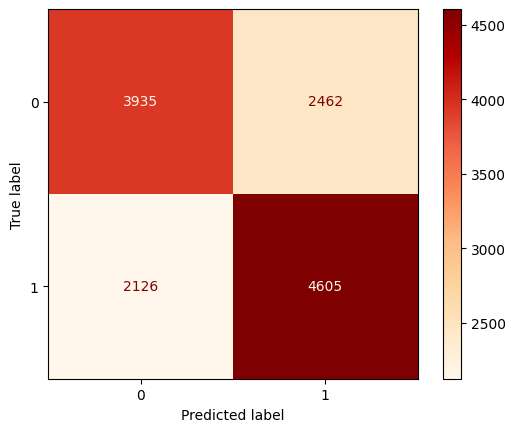

In [441]:
auc_xg = roc_auc_score(y_pred_xg, y_test)
acc_xg = accuracy_score(y_pred_xg, y_test)

print('AUC Score:', auc_xg.round(5))
print('Accuracy Score:', acc_xg.round(5))

# Assuming you have true labels in 'y_true' and predicted labels in 'y_pred'
cm = confusion_matrix(y_test, y_pred_xg)

# Create the ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(cm)

# Set the colormap to red and orange
cmap = plt.cm.get_cmap('OrRd')

# Plot the confusion matrix with the chosen colormap
cm_display.plot(cmap=cmap);

## Evaluating Profit/Loss

We can also look at the predicted probabilities for our test set and see how they compare to Bet365 odds. 

First we create a function to add predicted values and probabilities to our odds_win_test dataframe:

In [442]:
def add_preds_probs(odds_win_df, X_test, model):

    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Get probabilities
    y_prob = model.predict_proba(X_test)

    # Convert probabilities to odds format
    y_prob = 1/y_prob

    # Get only probability of a win
    y_prob = [prob[1] for prob in y_prob]

    # Add to odds_win_df
    odds_win_df['model_odds'] = y_prob
    odds_win_df['pred_win'] = y_pred

    return odds_win_df

In [443]:
odds_win_df = add_preds_probs(odds_win_test, X_test, xg)

We can define functions for calculating profit/loss in different scenarios:

In [444]:
# Function to calculate returns by betting on favourite:

def returns_from_fav(odds_win_df):
    # Filter the DataFrame for rows where the odds are less than or equal to 2.00
    filtered_df = odds_win_df[odds_win_df['odds'] <= 1.90].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total return from betting on favourite: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_fav(odds_win_df)

Total return from betting on favourite: £-1300.19
Total staked: £inf


In [445]:
# Function to calculate returns if we bet on every player the model predicted would win:

def returns_from_model_pred_win(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a win
    filtered_df = odds_win_df[odds_win_df['pred_win'] == 1].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on player model predicted to win: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_model_pred_win(odds_win_df)


Total returns from betting on player model predicted to win: £-1237.22
Total staked: £inf


In [446]:
def returns_from_lower_odds(odds_win_df):
    # Filter the DataFrame for rows where the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[odds_win_df['model_odds'] < odds_win_df['odds']].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_lower_odds(odds_win_df)


Total returns from betting on players where model odds are lower than B365: £-421.44
Total staked: £4503.79


In [447]:
# Function to calculate returns if we only bet on players where the model's odds 
# were lower than the bookmaker odds and who the model predicted would win:
   
def returns_lower_odds_and_pred_win(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a win and the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[(odds_win_df['pred_win'] == 1) & (odds_win_df['model_odds'] < odds_win_df['odds'])].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365 and model predicted to win: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_lower_odds_and_pred_win(odds_win_df)


Total returns from betting on players where model odds are lower than B365 and model predicted to win: £-329.61
Total staked: £3305.98


In [448]:
# Function to calculate returns if we only bet on players where the model's odds 
# were lower than the bookmaker odds and who the model predicted would lose:
   
def returns_lower_odds_and_pred_lose(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a loss and the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[(odds_win_df['pred_win'] == 0) & (odds_win_df['model_odds'] < odds_win_df['odds'])].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_lower_odds_and_pred_lose(odds_win_df)

Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £-91.84
Total staked: £1197.81


## Evaluating on 2023 Results

First we load the dataset:

In [449]:
df_2023 = pd.read_excel(r'2023_dataset_wta\2023.xlsx')

Then we can run through the same pre-processing steps as before:

In [450]:
# Create winner and loser dataframes
df_winners_2023, df_losers_2023 = create_winner_loser_dfs(df_2023)

In [451]:
# Combine dataframes
match_df_2023 = combine_winners_losers_dfs(df_winners_2023, df_losers_2023) 

In [452]:
# Create prior match features
match_df_2023 = create_prior_match_features(match_df_2023)

In [453]:
# Extract odds data 
odds_win_df_2023 = extract_odds_df(match_df_2023)

In [454]:
# Create prior score features
match_df_2023 = create_prior_score_features(match_df_2023)

In [455]:
# Load model
xg = pickle.load(open('xg_model.pkl', 'rb'))

In [456]:
# Add predictions and probabilities
odds_win_df_2023 = add_preds_probs(odds_win_df_2023, match_df_2023, xg)

We can now look at returns for 2023 matches:

In [458]:
returns_from_fav(odds_win_df_2023)
returns_from_model_pred_win(odds_win_df_2023)
returns_from_lower_odds(odds_win_df_2023)
returns_lower_odds_and_pred_win(odds_win_df_2023)
returns_lower_odds_and_pred_lose(odds_win_df_2023)

Total return from betting on favourite: £-17.45
Total staked: £2491.06
Total returns from betting on player model predicted to win: £-25.28
Total staked: £2503.38
Total returns from betting on players where model odds are lower than B365: £-34.53
Total staked: £636.45
Total returns from betting on players where model odds are lower than B365 and model predicted to win: £-42.98
Total staked: £560.41
Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £8.45
Total staked: £76.04
